In [1]:
using RandomMeas

In [3]:
N = 4
depth = 5
cutoff = 1e-4
ξ = siteinds("Qubit", N)
ψ, ψ2, ρ, F = MPS[], MPO[], MPO[], Float64[]

#initial states
push!(ψ,MPS(ξ, ["Dn" for n in 1:N]));
push!(ψ2, outer(ψ[1]', ψ[1]));
push!(ρ,outer(ψ[1]',ψ[1]));
push!(F,1.)

#random circuit and noise parameters
circuit = random_circuit(ξ,depth)
p = 0.1*rand(N)
@showprogress dt=1 for d in 1:depth
            push!(ψ,apply(circuit,ψ[d];cutoff=cutoff))
            
            #each random circuit layer is followed by local depolarization with probabilities p 
            ψ2t = apply(circuit, ψ2[d], apply_dag=true; cutoff=cutoff)
            push!(ψ2, apply_depo_channel(ψ2t, p))
            
            push!(ρ, apply(circuit, ρ[d], apply_dag=true; cutoff=cutoff))

            push!(F, real(inner(ψ2[d+1], ρ[d+1])))
end

In [4]:
#Perform Randomized measurements
NU=200
NM=2000

measurement_group = Vector{MeasurementGroup}(undef,depth+1)
@showprogress dt=1 for d in 1:depth+1
    measurement_group[d] = MeasurementGroup(ρ[d],NU,NM;mode=Dense);
end

Progress: 100%|█████████████████████████████████████████| Time: 0:00:10


In [ ]:
# F_e = zeros(Float64,depth+1)
# for d in 1:depth+1
#     shadow_d = get_dense_shadows(measurement_group[d])
#     F_e[d] = real(get_expect_shadow(outer(ψ[d]',ψ[d]),shadow_d))
# end

In [ ]:
F_e = zeros(Float64,depth+1)
for d in 1:depth+1
    shadow_d = get_dense_shadows(measurement_group[d])
    F_e[d] = real(get_expect_shadow(ψ2[d],shadow_d))
end

In [ ]:
# F_CRM = copy(F_e).+1

# for d in 1:depth+1
#     for r in 1:NU
#         data = measurement_group[d].measurements[r]
#         P = MeasurementProbability(ψ2[d],data.measurement_setting)
#         shadow_sigma = DenseShadow(P)
#         # F_CRM[d] -= real(get_expect_shadow(outer(ψ[d]',ψ[d]),shadow_sigma))/NU
#         F_CRM[d] -= real(get_expect_shadow(ψ2[d],shadow_sigma))/NU
#     end
# end

UndefVarError: UndefVarError: `d` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

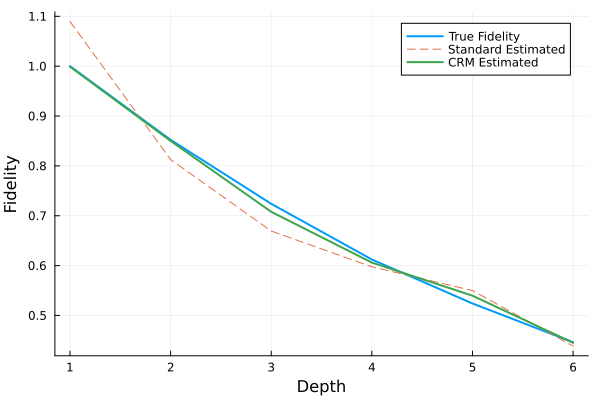

In [9]:
# ... (前半はそのまま) ...

F_CRM = zeros(Float64, depth+1)

for d in 1:depth+1
    # 1. 補正項（Bias）の計算
    term_correction = 0.0
    for r in 1:NU
        data = measurement_group[d].measurements[r]
        # Prior (ψ2) に基づく確率分布
        P = MeasurementProbability(ψ2[d], data.measurement_setting)
        # シミュレーション上のシャドウ
        shadow_sigma = DenseShadow(P)
        
        # Prior に対する期待値の積算
        term_correction += real(get_expect_shadow(ψ2[d], shadow_sigma))
    end
    
    # 2. バイアスの平均値
    bias_mean = term_correction / NU
    
    # 3. Prior (ψ2) の純粋度（Purity）を計算
    # 混合状態なので 1.0 ではなく < 1.0 になります
    purity_sigma = real(inner(ψ2[d], ψ2[d]))
    
    # 4. CRMの正しい式: F_e - (バイアス - 純粋度)
    F_CRM[d] = F_e[d] - (bias_mean - purity_sigma)
end

using Plots
plot(1:depth+1, F, label="True Fidelity", lw=2)
plot!(1:depth+1, F_e, label="Standard Estimated", linestyle=:dash)
plot!(1:depth+1, F_CRM, label="CRM Estimated", lw=2)
xlabel!("Depth")
ylabel!("Fidelity")

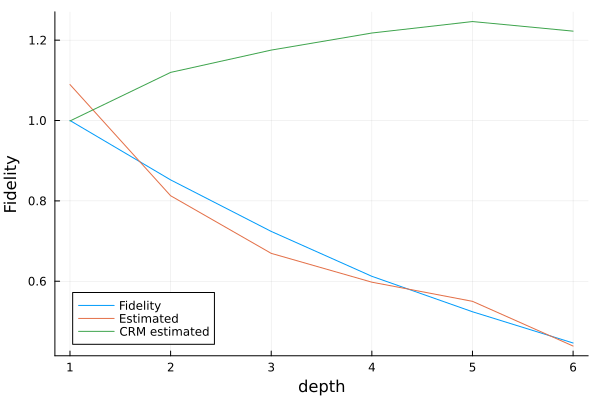

In [ ]:
# using Plots
# Plots.plot(1:depth+1,F,label="Fidelity")
# plot!(1:depth+1,F_e,label="Estimated")
# plot!(1:depth+1,F_CRM,label="CRM estimated")
# xlabel!("depth")
# ylabel!("Fidelity")

=== Step 1: Generating States (Time Evolution) ===
Target Depth: 5


Progress: 100%|█████████████████████████████████████████| Time: 0:00:02


True Fidelity at final depth: 0.7424195201443329
Purity of Prior (ψ2): 0.9998635739954325

=== Step 2: Convergence Analysis (Varying Measurements) ===
Starting estimation loop...
Total=100 (NU=10, NM=10): Std=0.687, CRM=0.785
Total=300 (NU=15, NM=20): Std=0.752, CRM=0.769
Total=1000 (NU=20, NM=50): Std=0.7, CRM=0.775
Total=5000 (NU=50, NM=100): Std=0.723, CRM=0.76
Total=20000 (NU=100, NM=200): Std=0.756, CRM=0.75
Total=100000 (NU=200, NM=500): Std=0.755, CRM=0.752
Total=500000 (NU=500, NM=1000): Std=0.759, CRM=0.751


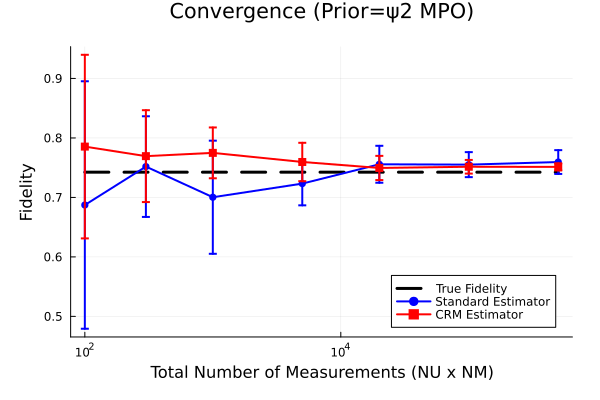

In [10]:
using ITensors
using RandomMeas
using Plots
using Statistics

# --- 1. 初期設定と状態準備 ---
N = 4           # 量子ビット数
depth = 5       # 回路の深さ
cutoff = 1e-4   # SVDの切り捨て誤差

# 変数の準備
ξ = siteinds("Qubit", N)
ψ = MPS(ξ, ["Dn" for n in 1:N])     # 理想状態の種 (MPS)
ψ2 = outer(ψ', ψ)                   # ★ Prior: 理想状態の密度行列 (MPO)
ρ  = outer(ψ', ψ)                   # ★ Target: 実験状態 (MPO)

circuit = random_circuit(ξ, depth)  # ランダム回路生成
p = 0.05 * rand(N)                  # ノイズ強度

println("=== Step 1: Generating States (Time Evolution) ===")
println("Target Depth: $depth")

# 時間発展
@showprogress dt=1 for d in 1:depth
    # Prior (ψ2) の更新:
    # ここでは「ノイズなしの理想的なMPO」として更新します
    # (もしPriorにもノイズを入れたい場合は、ここにapply_depo_channelを追加してください)
    global ψ2 = apply(circuit, ψ2, apply_dag=true; cutoff=cutoff)
    
    # Target (ρ) の更新:
    # こちらはゲート操作 + ノイズ付与を行います
    ρt = apply(circuit, ρ, apply_dag=true; cutoff=cutoff)
    global ρ = apply_depo_channel(ρt, p)
end

# 「正解」のFidelityを計算
# Prior(ψ2) と Target(ρ) の重なり: Tr(ψ2† ρ)
# ψ2が純粋状態なら <ψ|ρ|ψ> と一致します
true_fidelity = real(inner(ψ2, ρ))
println("True Fidelity at final depth: $true_fidelity")

# ★Prior(ψ2)の純粋度(Purity)を計算しておく
# CRMの式で「1.0」の代わりにこれを使います
purity_prior = real(inner(ψ2, ψ2))
println("Purity of Prior (ψ2): $purity_prior")

println("\n=== Step 2: Convergence Analysis (Varying Measurements) ===")

# --- 2. 測定回数を変化させながら実験 ---

settings_list = [
    (nu=10,   nm=10),    # Total = 100
    (nu=15,   nm=20),    # Total = 300
    (nu=20,   nm=50),    # Total = 1,000
    (nu=50,   nm=100),   # Total = 5,000
    (nu=100,  nm=200),   # Total = 20,000
    (nu=200,  nm=500),   # Total = 100,000
    (nu=500,  nm=1000)   # Total = 500,000
]

n_repeat = 15  # 統計用の繰り返し回数

total_shots_list = Float64[]
mean_standard = Float64[]
std_standard  = Float64[]
mean_crm      = Float64[]
std_crm       = Float64[]

println("Starting estimation loop...")

for (nu, nm) in settings_list
    total_shots = nu * nm
    push!(total_shots_list, total_shots)
    
    temp_standard = Float64[]
    temp_crm = Float64[]
    
    for i in 1:n_repeat
        # --- A. 実験データの生成 (Target: ρ) ---
        mg = MeasurementGroup(ρ, nu, nm; mode=RandomMeas.Dense)
        
        # --- B. Standard Estimator ---
        shadow_rho = get_dense_shadows(mg)
        
        # リスト対応の平均化処理
        # 観測量として ψ2 (MPO) を使います
        if isa(shadow_rho, Vector)
             val_std = mean([real(get_expect_shadow(ψ2, s)) for s in shadow_rho])
        else
             val_std = real(get_expect_shadow(ψ2, shadow_rho))
        end
        push!(temp_standard, val_std)
        
        # --- C. CRM Estimator (Prior: ψ2) ---
        term_correction = 0.0
        
        for r in 1:nu
            setting = mg.measurements[r].measurement_setting
            
            # ★ここが変わりました: ψ(MPS) ではなく ψ2(MPO) を引数に渡します
            P_sigma = MeasurementProbability(ψ2, setting)
            
            shadow_sigma = DenseShadow(P_sigma)
            
            # Priorに対する期待値の積算 (観測量 ψ2)
            term_correction += real(get_expect_shadow(ψ2, shadow_sigma))
        end
        
        # CRMの式: F_std - (Correction_Mean - Purity_Prior)
        # 純粋度 purity_prior (通常は1.0) を引くことで汎用的に対応
        f_crm = val_std - (term_correction / nu - purity_prior)
        push!(temp_crm, f_crm)
    end
    
    # 統計処理
    push!(mean_standard, mean(temp_standard))
    push!(std_standard,  std(temp_standard))
    push!(mean_crm,      mean(temp_crm))
    push!(std_crm,       std(temp_crm))
    
    println("Total=$(Int(total_shots)) (NU=$nu, NM=$nm): Std=$(round(mean(temp_standard), digits=3)), CRM=$(round(mean(temp_crm), digits=3))")
end

# --- 3. プロット作成 ---

true_line = fill(true_fidelity, length(total_shots_list))

p1 = plot(total_shots_list, true_line, 
    label="True Fidelity", 
    lw=3, color=:black, linestyle=:dash,
    xlabel="Total Number of Measurements (NU x NM)",
    ylabel="Fidelity",
    title="Convergence (Prior=ψ2 MPO)",
    legend=:bottomright,
    xscale=:log10,
    margin=5Plots.mm
)

plot!(p1, total_shots_list, mean_standard, 
    yerror=std_standard,
    label="Standard Estimator", 
    marker=:circle, lw=2, color=:blue,
    msc=:blue
)

plot!(p1, total_shots_list, mean_crm, 
    yerror=std_crm,
    label="CRM Estimator", 
    marker=:square, lw=2, color=:red,
    msc=:red
)

display(p1)

## 近似精度変更

=== Step 1: Generating States ===
Experiment Noise: 0.02, Prior Noise: 1.0
True Fidelity (Target): 0.9168188189573988
Prior Accuracy (Overlap with Ideal): 0.06244178710707284

=== Step 2: Convergence Analysis ===
Total=100: Std=0.86, CRM=0.86
Total=300: Std=0.942, CRM=0.942
Total=1000: Std=0.929, CRM=0.929
Total=5000: Std=0.96, CRM=0.96
Total=20000: Std=0.946, CRM=0.946
Total=100000: Std=0.941, CRM=0.941
Total=500000: Std=0.93, CRM=0.93


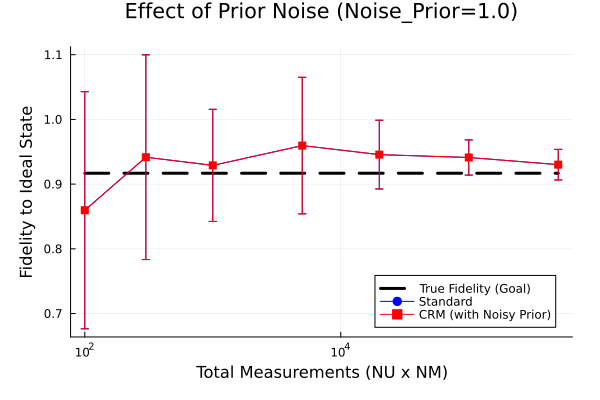

In [27]:
using ITensors
using RandomMeas
using Plots
using Statistics

# --- 1. パラメータ設定 ---
N = 4           # 量子ビット数
depth = 5       # 回路の深さ
cutoff = 1e-4   # SVD誤差
# cutoff = 1e-12

# ★ここで近似精度と実験環境をコントロールします★
noise_strength_exp   = 0.02  # 実験機のノイズレベル (Target ρ)
noise_strength_prior = 1.00  # 近似計算の精度 (Prior ψ2) -> 0.0なら完璧、大きいほど近似が悪い

# ノイズ配列の生成
p_exp   = noise_strength_exp   * rand(N)
p_prior = noise_strength_prior * rand(N)

# --- 2. 状態生成 (3つのラインを走らせます) ---
println("=== Step 1: Generating States ===")
println("Experiment Noise: $noise_strength_exp, Prior Noise: $noise_strength_prior")

# インデックス定義
ξ = siteinds("Qubit", N)

# (1) 理想状態 (MPS): 真のゴール
ψ = MPS(ξ, ["Dn" for n in 1:N]) 

# (2) Prior (MPO): ノイズありの理論モデル
ψ2 = outer(ψ', ψ)

# (3) 実験状態 (MPO): 実機上の状態
ρ = outer(ψ', ψ)

circuit = random_circuit(ξ, depth)

@showprogress dt=1 for d in 1:depth
    # --- A. 理想状態 (Noise Free) ---
    global ψ = apply(circuit, ψ; cutoff=cutoff)
    
    # --- B. Prior (Approximation) ---
    # 近似モデルにもノイズ(p_prior)が入る
    ψ2t = apply(circuit, ψ2, apply_dag=true; cutoff=cutoff)
    global ψ2 = apply_depo_channel(ψ2t, p_prior)
    
    # --- C. 実験状態 (Experiment) ---
    # 実機には実機のノイズ(p_exp)が入る
    ρt = apply(circuit, ρ, apply_dag=true; cutoff=cutoff)
    global ρ = apply_depo_channel(ρt, p_exp)
end

# --- 評価基準の計算 ---

# 1. 真のFidelity (実験状態 ρ が 理想状態 ψ にどれだけ近いか)
# これを推定するのが今回のゴールです。
true_fidelity = real(inner(ψ', ρ, ψ))
println("True Fidelity (Target): $true_fidelity")

# 2. Priorの正確さ (近似モデル ψ2 が 理想状態 ψ とどれだけ重なっているか)
# CRMの補正項で必要になります。
overlap_prior = real(inner(ψ', ψ2, ψ))
println("Prior Accuracy (Overlap with Ideal): $overlap_prior")


# --- 3. 測定回数を変えて検証 ---
println("\n=== Step 2: Convergence Analysis ===")

settings_list = [
    (nu=10,   nm=10),    # Total = 100
    (nu=15,   nm=20),    # Total = 300
    (nu=20,   nm=50),    # Total = 1,000
    (nu=50,   nm=100),   # Total = 5,000
    (nu=100,  nm=200),   # Total = 20,000
    (nu=200,  nm=500),   # Total = 100,000
    (nu=500,  nm=1000)   # Total = 500,000
]
n_repeat = 15

total_shots_list = Float64[]
mean_standard = Float64[]
std_standard  = Float64[]
mean_crm      = Float64[]
std_crm       = Float64[]

for (nu, nm) in settings_list
    total_shots = nu * nm
    push!(total_shots_list, total_shots)
    
    temp_standard = Float64[]
    temp_crm = Float64[]
    
    for i in 1:n_repeat
        # --- A. 実験データの取得 (Target: ρ) ---
        mg = MeasurementGroup(ρ, nu, nm; mode=RandomMeas.Dense)
        shadow_rho = get_dense_shadows(mg)
        
        # --- B. Standard Estimator ---
        # 観測したいのは「理想状態 ψ」とのFidelity
        obs = outer(ψ', ψ) # 観測量 O = |ψ><ψ|
        
        if isa(shadow_rho, Vector)
             val_std = mean([real(get_expect_shadow(obs, s)) for s in shadow_rho])
        else
             val_std = real(get_expect_shadow(obs, shadow_rho))
        end
        push!(temp_standard, val_std)
        
        # --- C. CRM Estimator ---
        term_correction = 0.0
        
        for r in 1:nu
            setting = mg.measurements[r].measurement_setting
            
            # Prior (ψ2) を使って確率分布を計算
            # ★ここが重要: 近似精度の悪い ψ2 を使ってシミュレーションする
            P_sigma = MeasurementProbability(ψ2, setting)
            shadow_sigma = DenseShadow(P_sigma)
            
            # シミュレーション上のバイアス (観測量 O に対する期待値)
            term_correction += real(get_expect_shadow(obs, shadow_sigma))
        end
        
        # CRM公式: F_std - (Bias_Simulated - True_Overlap_Prior)
        # Prior自体がズレているので、overlap_prior (1.0ではない) を引きます
        f_crm = val_std - (term_correction / nu - overlap_prior)
        push!(temp_crm, f_crm)
    end
    
    push!(mean_standard, mean(temp_standard))
    push!(std_standard,  std(temp_standard))
    push!(mean_crm,      mean(temp_crm))
    push!(std_crm,       std(temp_crm))
    
    println("Total=$(Int(total_shots)): Std=$(round(mean(temp_standard),digits=3)), CRM=$(round(mean(temp_crm),digits=3))")
end

# --- 4. プロット ---
true_line = fill(true_fidelity, length(total_shots_list))

p1 = plot(total_shots_list, true_line, 
    label="True Fidelity (Goal)", 
    lw=3, color=:black, linestyle=:dash,
    xlabel="Total Measurements (NU x NM)",
    ylabel="Fidelity to Ideal State",
    title="Effect of Prior Noise (Noise_Prior=$(noise_strength_prior))",
    legend=:bottomright,
    xscale=:log10, margin=5Plots.mm
)

plot!(p1, total_shots_list, mean_standard, yerror=std_standard,
    label="Standard", marker=:circle, color=:blue, msc=:blue)

plot!(p1, total_shots_list, mean_crm, yerror=std_crm,
    label="CRM (with Noisy Prior)", marker=:square, color=:red, msc=:red)

display(p1)

Images will be saved to: /Users/tatsuyamahiroshitaira/Desktop/GraphResults_CRM_PriorSweep
=== Starting Simulation Loop ===

------------------------------------------------
Processing Prior Noise Strength = 0.0
  True Fidelity (Target): 0.8807346104456824
  Prior Accuracy (Overlap): 0.9998185963469538
  -> Saved graph to: crm_prior_noise_0.0.png

------------------------------------------------
Processing Prior Noise Strength = 0.1
  True Fidelity (Target): 0.8730549297941959
  Prior Accuracy (Overlap): 0.478796982323865
  -> Saved graph to: crm_prior_noise_0.1.png

------------------------------------------------
Processing Prior Noise Strength = 0.3
  True Fidelity (Target): 0.873955726579895
  Prior Accuracy (Overlap): 0.1856675510185623
  -> Saved graph to: crm_prior_noise_0.3.png

------------------------------------------------
Processing Prior Noise Strength = 0.5
  True Fidelity (Target): 0.8778825694957932
  Prior Accuracy (Overlap): 0.07514376498012751
  -> Saved graph to: cr

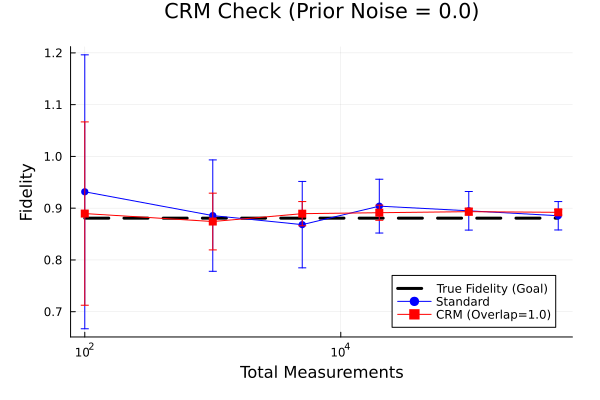

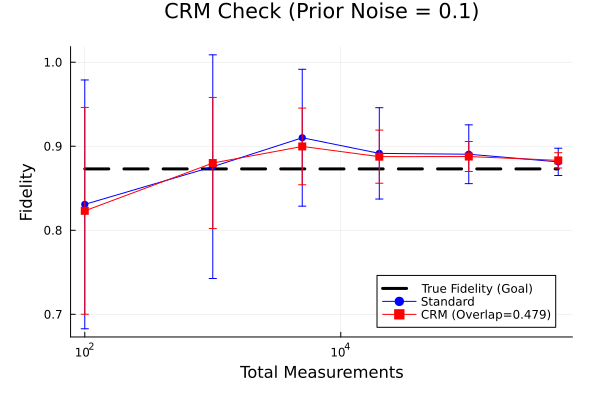

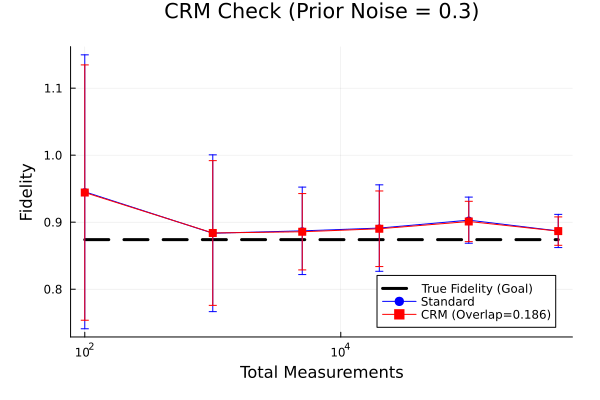

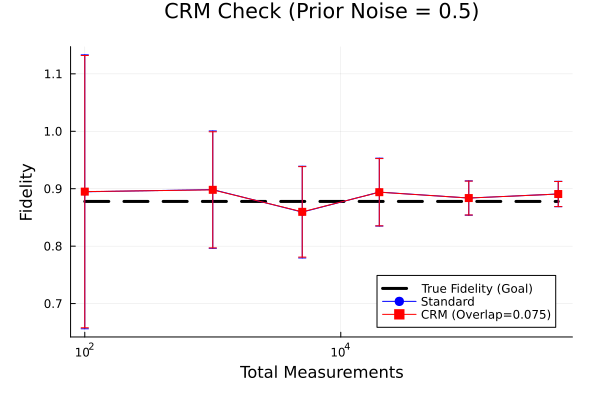

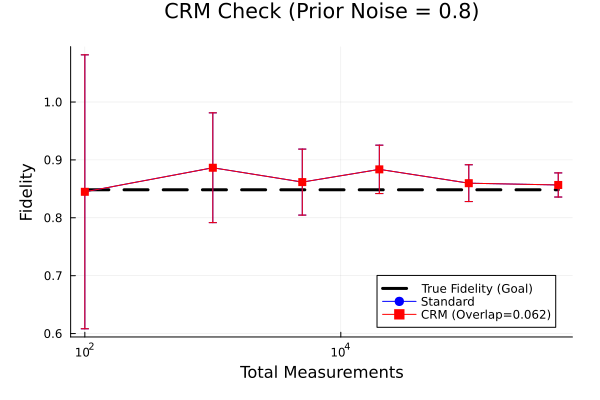

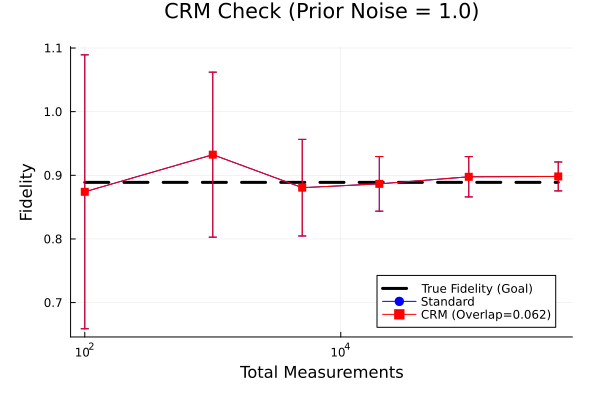

In [56]:
using ITensors
using RandomMeas
using Plots
using Statistics

# --- 0. 保存先の準備 ---
desktop_path = joinpath(homedir(), "Desktop", "GraphResults_CRM_PriorSweep")
mkpath(desktop_path)
println("Images will be saved to: $desktop_path")

# --- 1. 共通パラメータ設定 ---
N = 4           # 量子ビット数
depth = 5       # 回路の深さ
cutoff = 1e-4   # SVD誤差

# 実験機のノイズレベルは固定 (Target ρ)
noise_strength_exp = 0.02

# ★ここを変化させます (Prior ψ2 の精度)★
prior_noise_levels = [0.0, 0.1, 0.3, 0.5, 0.8, 1.0]

# 回路は全条件で共通にするため、ここで固定
ξ = siteinds("Qubit", N)
circuit = random_circuit(ξ, depth)

println("=== Starting Simulation Loop ===")

# --- 2. ノイズレベルごとのループ開始 ---
for noise_val_prior in prior_noise_levels
    println("\n------------------------------------------------")
    println("Processing Prior Noise Strength = $noise_val_prior")
    
    # ノイズ配列の生成 (Expは固定、Priorは可変)
    # ※乱数シードの影響を避けるため、毎回生成でも良いですが、
    # 厳密な比較のためp_expも固定したい場合はループ外に出してください。
    # ここでは「その都度ランダムなノイズが乗る」想定で回します。
    p_exp   = noise_strength_exp * rand(N)
    p_prior = noise_val_prior    * rand(N)

    # --- 状態生成 (リセット & 再計算) ---
    
    # (1) 理想状態 (MPS)
    ψ = MPS(ξ, ["Dn" for n in 1:N]) 
    # (2) Prior (MPO)
    ψ2 = outer(ψ', ψ)
    # (3) 実験状態 (MPO)
    ρ = outer(ψ', ψ)

    # 時間発展
    for d in 1:depth
        # A. 理想状態
        ψ = apply(circuit, ψ; cutoff=cutoff)
        
        # B. Prior (Approximation) - 可変ノイズ p_prior を適用
        ψ2t = apply(circuit, ψ2, apply_dag=true; cutoff=cutoff)
        ψ2 = apply_depo_channel(ψ2t, p_prior)
        
        # C. 実験状態 (Experiment) - 固定ノイズ p_exp を適用
        ρt = apply(circuit, ρ, apply_dag=true; cutoff=cutoff)
        ρ = apply_depo_channel(ρt, p_exp)
    end

    # --- 評価基準の計算 ---
    # 真のFidelity (Target)
    true_fidelity = real(inner(ψ', ρ, ψ))
    println("  True Fidelity (Target): $true_fidelity")

    # Priorの正確さ (Overlap)
    overlap_prior = real(inner(ψ', ψ2, ψ))
    println("  Prior Accuracy (Overlap): $overlap_prior")

    # --- 3. 測定シミュレーション ---
    settings_list = [
        (nu=10,   nm=10),
        (nu=20,   nm=50),
        (nu=50,   nm=100),
        (nu=100,  nm=200),
        (nu=200,  nm=500),
        (nu=500,  nm=1000)
    ]
    n_repeat = 15

    total_shots_list = Float64[]
    mean_standard = Float64[]
    std_standard  = Float64[]
    mean_crm      = Float64[]
    std_crm       = Float64[]

    for (nu, nm) in settings_list
        total_shots = nu * nm
        push!(total_shots_list, total_shots)
        
        temp_standard = Float64[]
        temp_crm = Float64[]
        
        # 観測量 O = |ψ><ψ|
        obs = outer(ψ', ψ)
        
        for i in 1:n_repeat
            # --- A. 実験データの取得 (Target: ρ) ---
            mg = MeasurementGroup(ρ, nu, nm; mode=RandomMeas.Dense)
            shadow_rho = get_dense_shadows(mg)
            
            # --- B. Standard Estimator ---
            if isa(shadow_rho, Vector)
                 val_std = mean([real(get_expect_shadow(obs, s)) for s in shadow_rho])
            else
                 val_std = real(get_expect_shadow(obs, shadow_rho))
            end
            push!(temp_standard, val_std)
            
            # --- C. CRM Estimator ---
            term_correction = 0.0
            
            for r in 1:nu
                setting = mg.measurements[r].measurement_setting
                
                # ノイズの乗った Prior (ψ2) で補正項を計算
                P_sigma = MeasurementProbability(ψ2, setting)
                shadow_sigma = DenseShadow(P_sigma)
                
                term_correction += real(get_expect_shadow(obs, shadow_sigma))
            end
            
            # CRM公式
            f_crm = val_std - (term_correction / nu - overlap_prior)
            push!(temp_crm, f_crm)
        end
        
        push!(mean_standard, mean(temp_standard))
        push!(std_standard,  std(temp_standard))
        push!(mean_crm,      mean(temp_crm))
        push!(std_crm,       std(temp_crm))
    end

    # --- 4. プロット作成と保存 ---
    true_line = fill(true_fidelity, length(total_shots_list))

    p = plot(total_shots_list, true_line, 
        label="True Fidelity (Goal)", 
        lw=3, color=:black, linestyle=:dash,
        xlabel="Total Measurements",
        ylabel="Fidelity",
        title="CRM Check (Prior Noise = $noise_val_prior)",
        legend=:bottomright,
        xscale=:log10, 
        margin=5Plots.mm
    )

    plot!(p, total_shots_list, mean_standard, yerror=std_standard,
        label="Standard", marker=:circle, color=:blue, msc=:blue)

    plot!(p, total_shots_list, mean_crm, yerror=std_crm,
        label="CRM (Overlap=$(round(overlap_prior, digits=3)))", 
        marker=:square, color=:red, msc=:red)
    
    # ファイル保存
    file_name = "crm_prior_noise_$(noise_val_prior).png"
    save_full_path = joinpath(desktop_path, file_name)
    savefig(p, save_full_path)
    println("  -> Saved graph to: $file_name")
    
    # 画面にも表示（Jupyter環境等の場合）
    display(p)
end

println("\n=== All Simulations Completed ===")

## depoの強さによる変化

Generating Prior State (ψ2) with noise p=0.7 ...
True Purity of ψ2: 0.06250772595875059

=== Convergence Analysis of Prior Shadow ===
Total=100: Estimated=0.0624 (True=0.06250772595875059)
Total=1000: Estimated=0.0625 (True=0.06250772595875059)
Total=5000: Estimated=0.0625 (True=0.06250772595875059)
Total=20000: Estimated=0.0625 (True=0.06250772595875059)
Total=100000: Estimated=0.0625 (True=0.06250772595875059)
Total=500000: Estimated=0.0625 (True=0.06250772595875059)


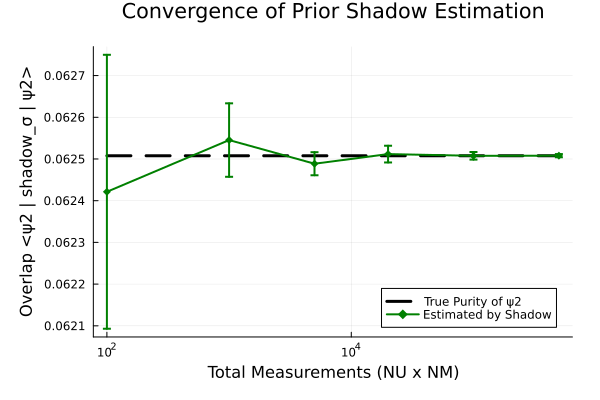

In [23]:
using ITensors
using RandomMeas
using Plots
using Statistics

# --- 1. 設定と状態準備 ---
N = 4
depth = 5
# cutoff = 1e-4
cutoff = 1e-12

# Priorのノイズ（近似の悪さ）を設定
noise_strength_prior = 0.70
p_prior = noise_strength_prior * rand(N)

println("Generating Prior State (ψ2) with noise p=$noise_strength_prior ...")

# 状態のインデックス
ξ = siteinds("Qubit", N)

# 理想状態の種
ψ_ideal = MPS(ξ, ["Dn" for n in 1:N])
# Prior (MPO) の初期化
ψ2 = outer(ψ_ideal', ψ_ideal)

# ランダム回路
circuit = random_circuit(ξ, depth)

# Priorの時間発展 (ノイズあり)
@showprogress dt=1 for d in 1:depth
    ψ2t = apply(circuit, ψ2, apply_dag=true; cutoff=cutoff)
    global ψ2 = apply_depo_channel(ψ2t, p_prior)
end

# --- 2. 真のFidelity (純粋度) の計算 ---
# 自分自身との重なり: Tr(ψ2 * ψ2)
true_purity = real(inner(ψ2, ψ2))
println("True Purity of ψ2: $true_purity")

# --- 3. 測定回数を変えて収束を確認 ---
println("\n=== Convergence Analysis of Prior Shadow ===")

settings_list = [
    (nu=10,   nm=10),    # Total = 100
    (nu=20,   nm=50),    # Total = 1,000
    (nu=50,   nm=100),   # Total = 5,000
    (nu=100,  nm=200),   # Total = 20,000
    (nu=200,  nm=500),   # Total = 100,000
    (nu=500,  nm=1000)   # Total = 500,000
]

n_repeat = 10  # 統計用試行回数

total_shots_list = Float64[]
mean_est = Float64[]
std_est  = Float64[]

for (nu, nm) in settings_list
    total_shots = nu * nm
    push!(total_shots_list, total_shots)
    
    temp_vals = Float64[]
    
    for i in 1:n_repeat
        # Prior ψ2 に対して測定シミュレーションを行う
        # 実験状態ρではなく、ψ2を測定対象にします
        mg = MeasurementGroup(ψ2, nu, nm; mode=RandomMeas.Dense)
        
        # シャドウの復元
        shadow_sigma = get_dense_shadows(mg)
        
        # 観測量として ψ2 自身を使用: Tr(ψ2 * shadow_sigma)
        # これが True Purity に収束するかを確認
        if isa(shadow_sigma, Vector)
            val = mean([real(get_expect_shadow(ψ2, s)) for s in shadow_sigma])
        else
            val = real(get_expect_shadow(ψ2, shadow_sigma))
        end
        
        push!(temp_vals, val)
    end
    
    push!(mean_est, mean(temp_vals))
    push!(std_est,  std(temp_vals))
    
    println("Total=$(Int(total_shots)): Estimated=$(round(mean(temp_vals), digits=4)) (True=$true_purity)")
end

# --- 4. プロット ---
true_line = fill(true_purity, length(total_shots_list))

p1 = plot(total_shots_list, true_line, 
    label="True Purity of ψ2", 
    lw=3, color=:black, linestyle=:dash,
    xlabel="Total Measurements (NU x NM)",
    ylabel="Overlap <ψ2 | shadow_σ | ψ2>", # 混合状態なので厳密には Tr(ψ2 σ)
    title="Convergence of Prior Shadow Estimation",
    legend=:bottomright,
    xscale=:log10,
    margin=5Plots.mm
)

plot!(p1, total_shots_list, mean_est, 
    yerror=std_est,
    label="Estimated by Shadow", 
    marker=:diamond, lw=2, color=:green, msc=:green
)

display(p1)

=== Starting Simulation ===

--- Processing Noise Strength = 0 ---
  True Purity: 1.0000000000000067


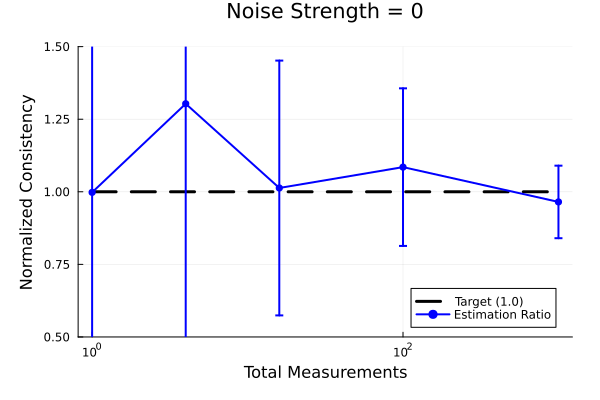

In [42]:
using ITensors
using RandomMeas
using Plots
using Statistics

# --- 1. 共通設定 ---
N = 4
depth = 5
cutoff = 1e-12

# 比較したいノイズレベルのリスト
# noise_levels = [0.0, 0.1, 0.3, 0.5, 0.7]
noise_levels = [0]


# 測定設定
settings_list = [
    (nu=1,   nm=1),
    (nu=2,   nm=2), 
    (nu=4,   nm=4), 
    (nu=10,   nm=10),    # Total = 100
    (nu=20,   nm=50),    # Total = 1,000
#     (nu=50,   nm=100),   # Total = 5,000
#     (nu=100,  nm=200),   # Total = 20,000
#     (nu=200,  nm=500),   # Total = 100,000
#     (nu=500,  nm=1000)   # Total = 500,000
 ]
n_repeat = 15

ξ = siteinds("Qubit", N)
circuit = random_circuit(ξ, depth)

println("=== Starting Simulation ===")

# --- 2. ノイズレベルごとのループ ---
for noise_val in noise_levels
    println("\n--- Processing Noise Strength = $noise_val ---")
    
    # ノイズ設定と状態生成
    p_prior = noise_val * ones(N)
    
    ψ_ideal = MPS(ξ, ["Dn" for n in 1:N])
    ψ2 = outer(ψ_ideal', ψ_ideal)
    
    # 時間発展
    for d in 1:depth
        ψ2t = apply(circuit, ψ2, apply_dag=true; cutoff=cutoff)
        global ψ2 = apply_depo_channel(ψ2t, p_prior)
    end
    
    # 真の純粋度
    true_purity = real(inner(ψ2, ψ2))
    println("  True Purity: $true_purity")
    
    # --- 測定ループ ---
    total_shots_list = Float64[]
    mean_ratios = Float64[]
    std_ratios  = Float64[]
    
    for (nu, nm) in settings_list
        total_shots = nu * nm
        push!(total_shots_list, total_shots)
        
        temp_ratios = Float64[]
        
        for i in 1:n_repeat
            mg = MeasurementGroup(ψ2, nu, nm; mode=RandomMeas.Dense)
            shadow_sigma = get_dense_shadows(mg)
            
            if isa(shadow_sigma, Vector)
                val_est = mean([real(get_expect_shadow(ψ2, s)) for s in shadow_sigma])
            else
                val_est = real(get_expect_shadow(ψ2, shadow_sigma))
            end
            
            push!(temp_ratios, val_est / true_purity)
        end
        
        push!(mean_ratios, mean(temp_ratios))
        push!(std_ratios,  std(temp_ratios))
    end
    
    # --- プロット作成 (ループ内で独立して作成) ---
    
    # 基準線 (1.0)
    target_line = fill(1.0, length(total_shots_list))
    
    # 個別のプロットオブジェクトを作成
    p = plot(total_shots_list, target_line, 
        label="Target (1.0)", 
        lw=3, color=:black, linestyle=:dash,
        xlabel="Total Measurements",
        ylabel="Normalized Consistency",
        title="Noise Strength = $noise_val",  # タイトルにノイズ量を表示
        legend=:bottomright,
        xscale=:log10,
        ylims=(0.5, 1.5), # 上下限を固定して比較しやすくする
        margin=5Plots.mm
    )
    
    # データをプロット
    plot!(p, total_shots_list, mean_ratios, 
        yerror=std_ratios,
        label="Estimation Ratio", 
        marker=:circle, lw=2, color=:blue, msc=:blue
    )
    
    # ★ここで表示★
    display(p)
end

=== Starting Simulation for Noise Levels: [0.0, 0.1, 0.3, 0.5, 0.7] ===

--- Processing Noise Strength = 0.0 ---
  True Purity: 1.0000000000000044

--- Processing Noise Strength = 0.1 ---
  True Purity: 0.10603576046265194

--- Processing Noise Strength = 0.3 ---
  True Purity: 0.0625545136901606

--- Processing Noise Strength = 0.5 ---
  True Purity: 0.06250003705368277

--- Processing Noise Strength = 0.7 ---
  True Purity: 0.06250000001440366


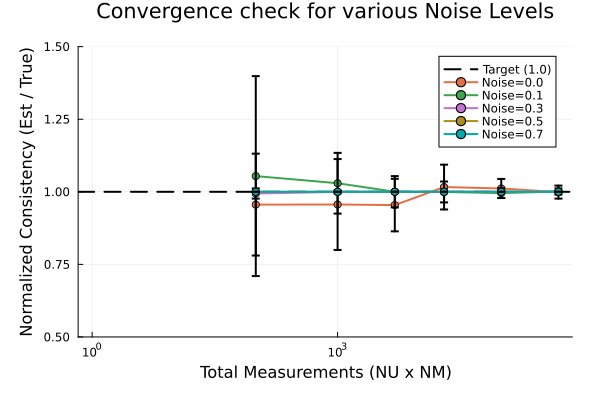

In [34]:
using ITensors
using RandomMeas
using Plots
using Statistics

# --- 1. 共通設定 ---
N = 4
depth = 5
cutoff = 1e-12  # 精度維持のため小さく設定

# 比較したいノイズレベルのリスト
noise_levels = [0.0, 0.1, 0.3, 0.5, 0.7]

# 測定設定 (横軸)
settings_list = [
    (nu=10,   nm=10),    # Total = 100
    (nu=20,   nm=50),    # Total = 1,000
    (nu=50,   nm=100),   # Total = 5,000
    (nu=100,  nm=200),   # Total = 20,000
    (nu=200,  nm=500),   # Total = 100,000
    (nu=500,  nm=1000)   # Total = 500,000
]
n_repeat = 15 # 統計試行回数

# 回路は固定して、ノイズの影響だけを見ます
ξ = siteinds("Qubit", N)
circuit = random_circuit(ξ, depth)

# --- 2. プロットの準備 ---
# 結果をまとめるための空のプロットを作成
p_combined = plot(
    xlabel="Total Measurements (NU x NM)",
    ylabel="Normalized Consistency (Est / True)",
    title="Convergence check for various Noise Levels",
    legend=:topright,
    xscale=:log10,
    ylims=(0.5, 1.5),
    margin=5Plots.mm
)

# 基準線 (1.0) を引く
hline!(p_combined, [1.0], label="Target (1.0)", color=:black, linestyle=:dash, lw=2)

println("=== Starting Simulation for Noise Levels: $noise_levels ===")

# --- 3. ノイズレベルごとのループ ---
for noise_val in noise_levels
    println("\n--- Processing Noise Strength = $noise_val ---")
    
    # ノイズベクトルの作成 (すべて noise_val)
    p_prior = noise_val * ones(N)
    
    # 状態の生成 (毎回リセット)
    ψ_ideal = MPS(ξ, ["Dn" for n in 1:N])
    ψ2 = outer(ψ_ideal', ψ_ideal)
    
    # 時間発展
    for d in 1:depth
        ψ2t = apply(circuit, ψ2, apply_dag=true; cutoff=cutoff)
        global ψ2 = apply_depo_channel(ψ2t, p_prior)
    end
    
    # 真の純粋度 (基準値)
    true_purity = real(inner(ψ2, ψ2))
    println("  True Purity: $true_purity")
    
    # --- 測定ループ ---
    total_shots_list = Float64[]
    mean_ratios = Float64[]
    std_ratios  = Float64[]
    
    for (nu, nm) in settings_list
        total_shots = nu * nm
        push!(total_shots_list, total_shots)
        
        temp_ratios = Float64[]
        
        for i in 1:n_repeat
            mg = MeasurementGroup(ψ2, nu, nm; mode=RandomMeas.Dense)
            shadow_sigma = get_dense_shadows(mg)
            
            # 推定値の計算
            if isa(shadow_sigma, Vector)
                val_est = mean([real(get_expect_shadow(ψ2, s)) for s in shadow_sigma])
            else
                val_est = real(get_expect_shadow(ψ2, shadow_sigma))
            end
            
            # 比率 (推定値 / 真値) -> 1.0 になるはず
            push!(temp_ratios, val_est / true_purity)
        end
        
        push!(mean_ratios, mean(temp_ratios))
        push!(std_ratios,  std(temp_ratios))
    end
    
    # --- プロットに追加 ---
    # ノイズレベルごとに色を変えてプロット
    plot!(p_combined, total_shots_list, mean_ratios, 
        yerror=std_ratios,
        label="Noise=$(noise_val)", 
        marker=:circle, lw=2
    )
end

# --- 4. 最終結果の表示 ---
display(p_combined)

Images will be saved to: /Users/tatsuyamahiroshitaira/Desktop/GraphResults
=== Starting Simulation ===

--- Processing Noise Strength = 0.0 ---
  True Purity: 0.9999999999999967
  -> Saved graph to: noise_0.0.png

--- Processing Noise Strength = 0.05 ---
  True Purity: 0.2804354193816173
  -> Saved graph to: noise_0.05.png

--- Processing Noise Strength = 0.1 ---
  True Purity: 0.11225236353659246
  -> Saved graph to: noise_0.1.png

--- Processing Noise Strength = 0.15 ---
  True Purity: 0.07370165693492407
  -> Saved graph to: noise_0.15.png

--- Processing Noise Strength = 0.2 ---
  True Purity: 0.0649992341117511
  -> Saved graph to: noise_0.2.png

--- Processing Noise Strength = 0.25 ---
  True Purity: 0.0630550681209994
  -> Saved graph to: noise_0.25.png

--- Processing Noise Strength = 0.3 ---
  True Purity: 0.06262306498405626
  -> Saved graph to: noise_0.3.png


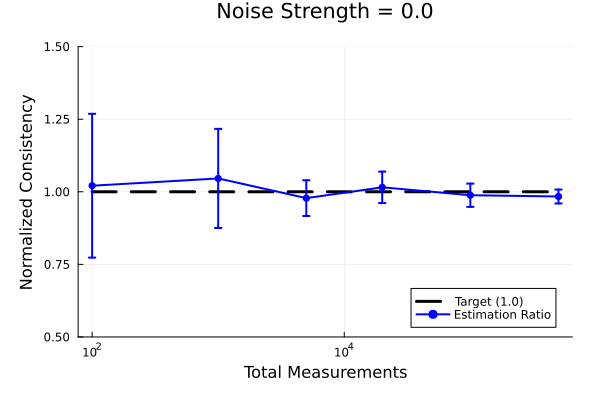

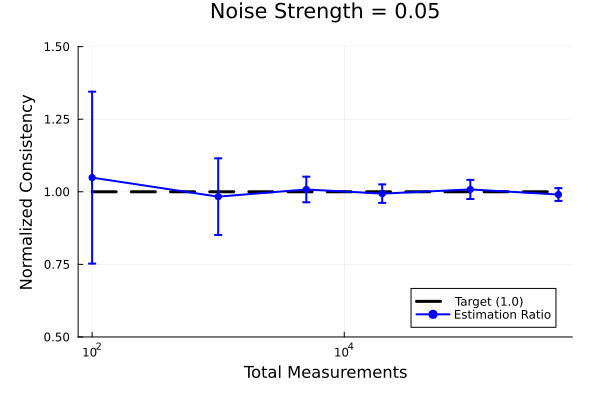

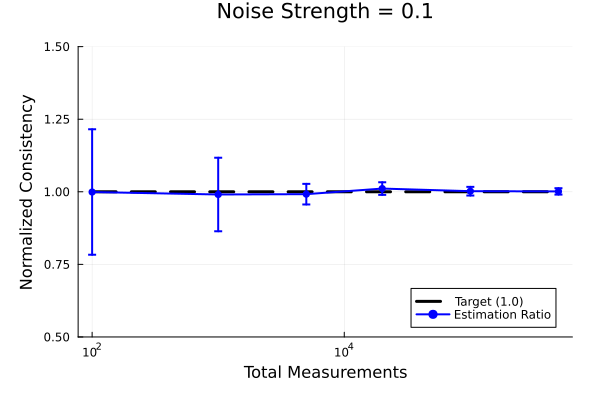

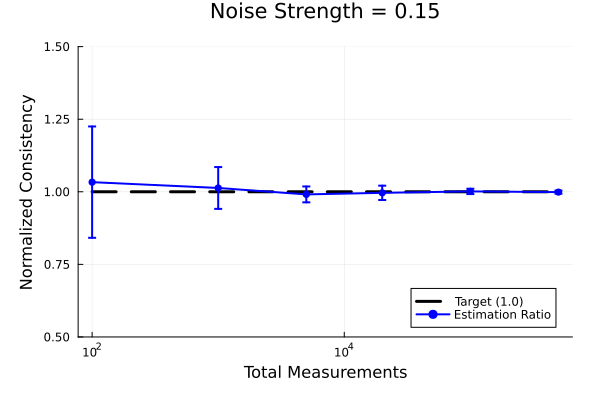

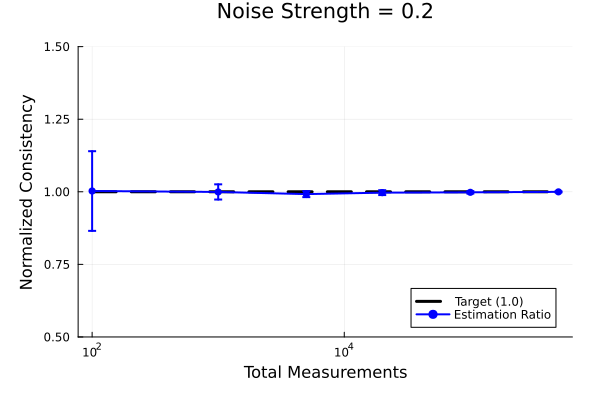

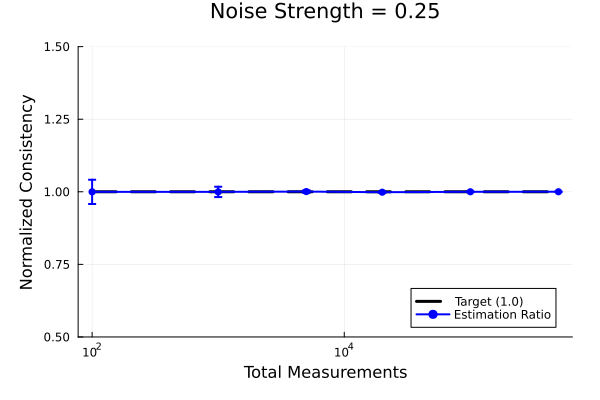

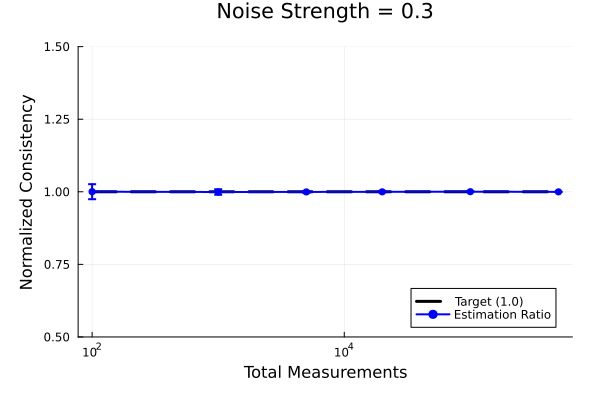

In [37]:
using ITensors
using RandomMeas
using Plots
using Statistics

# --- 0. 保存先の準備 (ここを追加) ---
# デスクトップのパスを取得して、専用フォルダを作成
desktop_path = joinpath(homedir(), "Desktop", "GraphResults")
mkpath(desktop_path) # フォルダがなければ作成、あればそのまま
println("Images will be saved to: $desktop_path")

# --- 1. 共通設定 ---
N = 4
depth = 5
cutoff = 1e-12

noise_levels = [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3]

settings_list = [
    (nu=10,   nm=10),
    (nu=20,   nm=50),
    (nu=50,   nm=100),
    (nu=100,  nm=200),
    (nu=200,  nm=500),
    (nu=500,  nm=1000)
]
n_repeat = 15

ξ = siteinds("Qubit", N)
circuit = random_circuit(ξ, depth)

println("=== Starting Simulation ===")

# --- 2. ノイズレベルごとのループ ---
for noise_val in noise_levels
    println("\n--- Processing Noise Strength = $noise_val ---")
    
    p_prior = noise_val * ones(N)
    
    ψ_ideal = MPS(ξ, ["Dn" for n in 1:N])
    ψ2 = outer(ψ_ideal', ψ_ideal)
    
    for d in 1:depth
        ψ2t = apply(circuit, ψ2, apply_dag=true; cutoff=cutoff)
        global ψ2 = apply_depo_channel(ψ2t, p_prior)
    end
    
    true_purity = real(inner(ψ2, ψ2))
    println("  True Purity: $true_purity")
    
    # --- 測定ループ ---
    total_shots_list = Float64[]
    mean_ratios = Float64[]
    std_ratios  = Float64[]
    
    for (nu, nm) in settings_list
        total_shots = nu * nm
        push!(total_shots_list, total_shots)
        temp_ratios = Float64[]
        
        for i in 1:n_repeat
            mg = MeasurementGroup(ψ2, nu, nm; mode=RandomMeas.Dense)
            shadow_sigma = get_dense_shadows(mg)
            
            if isa(shadow_sigma, Vector)
                val_est = mean([real(get_expect_shadow(ψ2, s)) for s in shadow_sigma])
            else
                val_est = real(get_expect_shadow(ψ2, shadow_sigma))
            end
            
            push!(temp_ratios, val_est / true_purity)
        end
        
        push!(mean_ratios, mean(temp_ratios))
        push!(std_ratios,  std(temp_ratios))
    end
    
    # --- プロット作成 ---
    target_line = fill(1.0, length(total_shots_list))
    
    p = plot(total_shots_list, target_line, 
        label="Target (1.0)", 
        lw=3, color=:black, linestyle=:dash,
        xlabel="Total Measurements",
        ylabel="Normalized Consistency",
        title="Noise Strength = $noise_val",
        legend=:bottomright,
        xscale=:log10,
        ylims=(0.5, 1.5),
        margin=5Plots.mm
    )
    
    plot!(p, total_shots_list, mean_ratios, 
        yerror=std_ratios,
        label="Estimation Ratio", 
        marker=:circle, lw=2, color=:blue, msc=:blue
    )
    
    # --- 画像の保存 (ここを追加) ---
    # ファイル名を動的に作成 (例: noise_0.1.png)
    file_name = "noise_$(noise_val).png"
    save_full_path = joinpath(desktop_path, file_name)
    
    # 保存実行
    savefig(p, save_full_path)
    println("  -> Saved graph to: $file_name")
    
    # 画面にも表示
    display(p)
end

## 厳密な定義のFidelity計算

非正定値行列のため、ルートの中身が負になり、虚数が出てしまう。

Images will be saved to: /Users/tatsuyamahiroshitaira/Desktop/GraphResults_Fidelity
=== Starting Simulation (Uhlmann Fidelity) ===

--- Processing Noise Strength = 0.0 ---
  -> Saved graph to: fidelity_noise_0.0.png

--- Processing Noise Strength = 0.1 ---
  -> Saved graph to: fidelity_noise_0.1.png

--- Processing Noise Strength = 0.3 ---
  -> Saved graph to: fidelity_noise_0.3.png

--- Processing Noise Strength = 0.5 ---
  -> Saved graph to: fidelity_noise_0.5.png

--- Processing Noise Strength = 0.7 ---
  -> Saved graph to: fidelity_noise_0.7.png


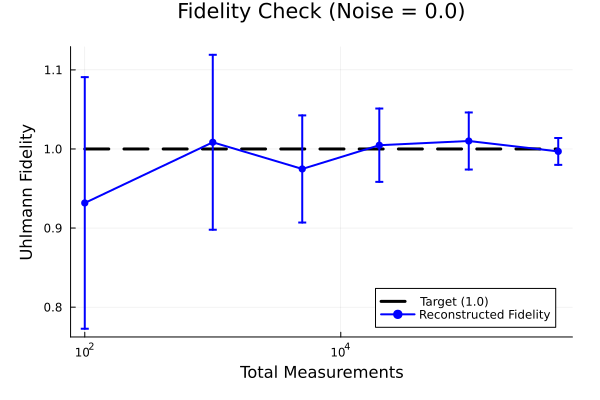

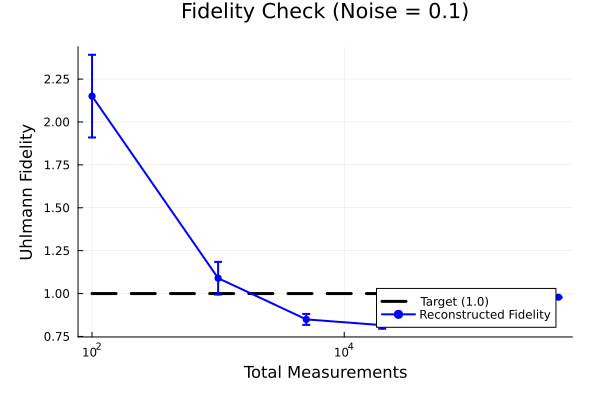

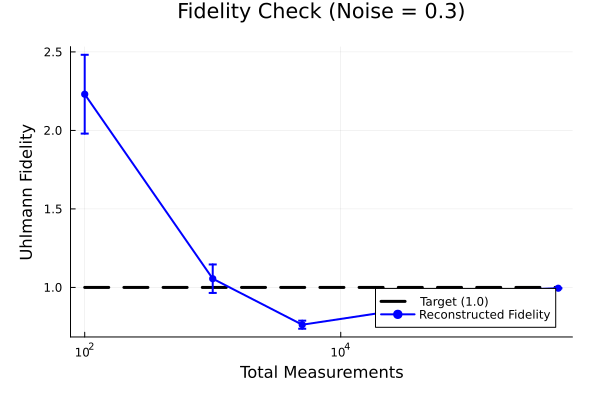

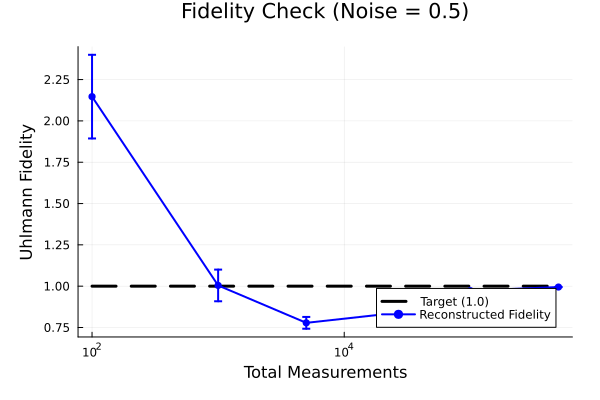

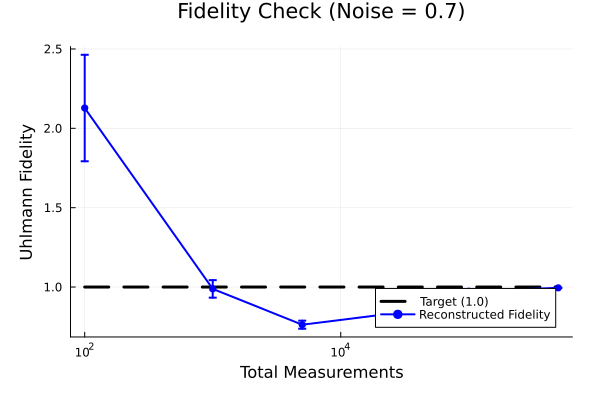

In [50]:
using ITensors
using RandomMeas
using Plots
using Statistics
using LinearAlgebra

# --- 0. 保存先の準備 ---
desktop_path = joinpath(homedir(), "Desktop", "GraphResults_Fidelity")
mkpath(desktop_path)
println("Images will be saved to: $desktop_path")

# --- Helper関数: 頑健なテンソル抽出 ---
function extract_inner_tensor(obj)
    if obj isa ITensor
        return obj
    end
    for name in fieldnames(typeof(obj))
        val = getfield(obj, name)
        if val isa ITensor
            return val
        end
    end
    error("Could not find an ITensor inside type $(typeof(obj)). Fields are: $(fieldnames(typeof(obj)))")
end

# --- Helper関数: 行列化関数 ---
function itensor_to_matrix(T_wrapper, s_inds::Vector{<:Index})
    T = extract_inner_tensor(T_wrapper)
    row_inds = [prime(s) for s in s_inds]
    col_inds = s_inds
    A_multi = Array(T, row_inds..., col_inds...)
    dim_total = 2^length(s_inds)
    return reshape(A_multi, dim_total, dim_total)
end

# MPO用ラッパー
function mpo_to_matrix(m::MPO)
    s = siteinds(m; plev=0)
    return itensor_to_matrix(prod(m), s)
end

# --- Helper関数: Uhlmann Fidelity ---
function calculate_uhlmann_fidelity(ρ::Matrix, σ::Matrix)
    ρ = Hermitian(ρ + ρ') / 2
    σ = Hermitian(σ + σ') / 2
    sqrt_ρ = sqrt(ρ)
    temp = sqrt_ρ * σ * sqrt_ρ
    val = tr(sqrt(Complex.(temp)))
    return real(val)^2
end

# --- 1. 共通設定 ---
N = 4
depth = 5
cutoff = 1e-12

noise_levels = [0.0, 0.1, 0.3, 0.5, 0.7]

settings_list = [
    (nu=10,   nm=10),
    (nu=20,   nm=50),
    (nu=50,   nm=100),
    (nu=100,  nm=200),
    (nu=200,  nm=500),
    (nu=500,  nm=1000)
]
n_repeat = 15

ξ = siteinds("Qubit", N)
circuit = random_circuit(ξ, depth)

println("=== Starting Simulation (Uhlmann Fidelity) ===")

# --- 2. ノイズレベルごとのループ ---
for noise_val in noise_levels
    println("\n--- Processing Noise Strength = $noise_val ---")
    
    p_prior = noise_val * ones(N)
    
    ψ_ideal = MPS(ξ, ["Dn" for n in 1:N])
    ψ2 = outer(ψ_ideal', ψ_ideal)
    
    for d in 1:depth
        ψ2t = apply(circuit, ψ2, apply_dag=true; cutoff=cutoff)
        global ψ2 = apply_depo_channel(ψ2t, p_prior)
    end
    
    true_rho_matrix = itensor_to_matrix(prod(ψ2), ξ)
    
    total_shots_list = Float64[]
    mean_fidelities = Float64[]
    std_fidelities  = Float64[]
    
    for (nu, nm) in settings_list
        total_shots = nu * nm
        push!(total_shots_list, total_shots)
        temp_fidelities = Float64[]
        
        for i in 1:n_repeat
            mg = MeasurementGroup(ψ2, nu, nm; mode=RandomMeas.Dense)
            shadows = get_dense_shadows(mg)
            
            est_matrix = zeros(ComplexF64, 2^N, 2^N)
            for s in shadows
                est_matrix += itensor_to_matrix(s, ξ)
            end
            est_matrix /= length(shadows)
            
            fid = calculate_uhlmann_fidelity(true_rho_matrix, est_matrix)
            push!(temp_fidelities, fid)
        end
        
        push!(mean_fidelities, mean(temp_fidelities))
        push!(std_fidelities,  std(temp_fidelities))
    end
    
    # --- プロット ---
    target_line = fill(1.0, length(total_shots_list))
    
    p = plot(total_shots_list, target_line, 
        label="Target (1.0)", 
        lw=3, color=:black, linestyle=:dash,
        xlabel="Total Measurements",
        ylabel="Uhlmann Fidelity",
        title="Fidelity Check (Noise = $noise_val)",
        legend=:bottomright,
        xscale=:log10,
        # ★ここを変更しました★
        # ylims=(0.0, 1.1), # 0.0から1.1まで広げて、全範囲を表示できるようにしました
        margin=5Plots.mm
    )
    
    plot!(p, total_shots_list, mean_fidelities, 
        yerror=std_fidelities,
        label="Reconstructed Fidelity", 
        marker=:circle, lw=2, color=:blue, msc=:blue
    )
    
    file_name = "fidelity_noise_$(noise_val).png"
    save_full_path = joinpath(desktop_path, file_name)
    savefig(p, save_full_path)
    println("  -> Saved graph to: $file_name")
    
    display(p)
end

## トレースノルム

Images will be saved to: /Users/tatsuyamahiroshitaira/Desktop/GraphResults_TraceNorm
=== Starting Simulation (Trace Distance) ===

--- Processing Noise Strength = 0.0 ---
  -> Saved graph to: trace_norm_noise_0.0.png

--- Processing Noise Strength = 0.1 ---
  -> Saved graph to: trace_norm_noise_0.1.png

--- Processing Noise Strength = 0.3 ---
  -> Saved graph to: trace_norm_noise_0.3.png

--- Processing Noise Strength = 0.5 ---
  -> Saved graph to: trace_norm_noise_0.5.png

--- Processing Noise Strength = 0.7 ---
  -> Saved graph to: trace_norm_noise_0.7.png

--- Processing Noise Strength = 1.0 ---
  -> Saved graph to: trace_norm_noise_1.0.png


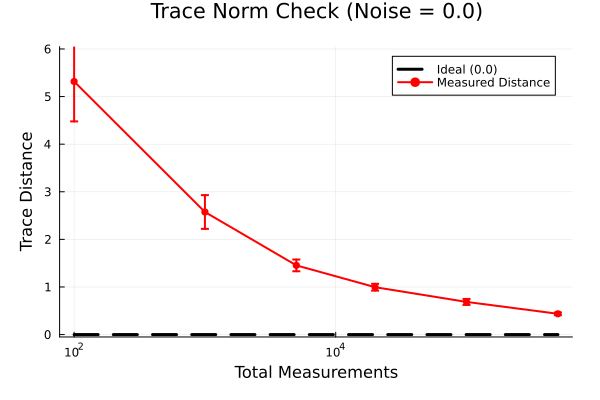

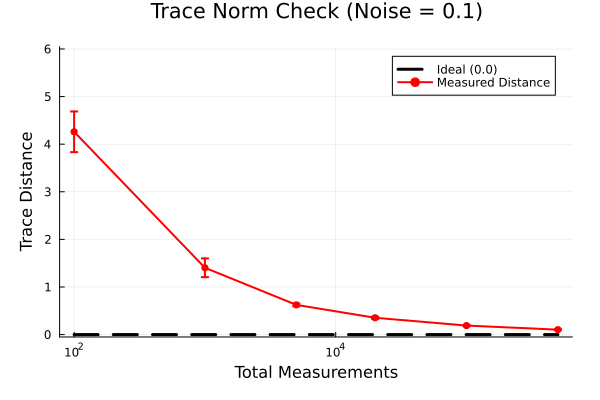

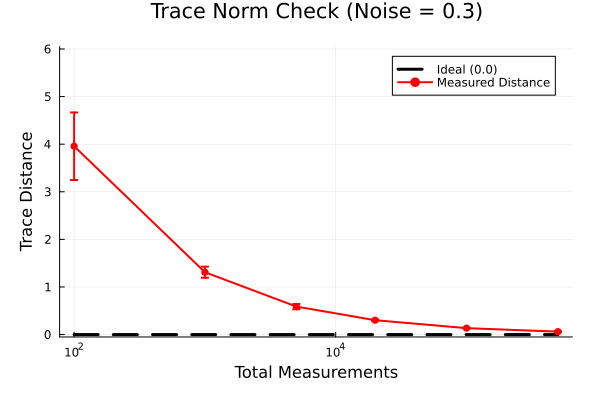

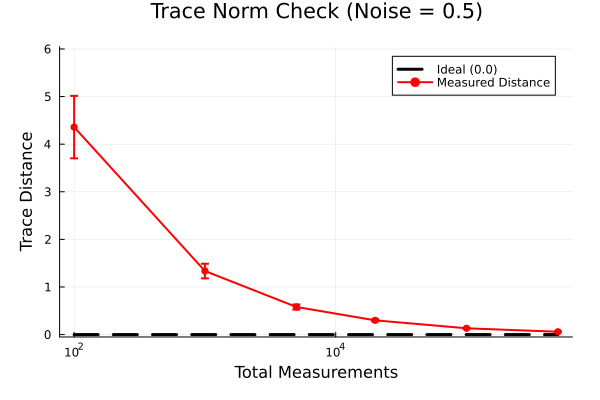

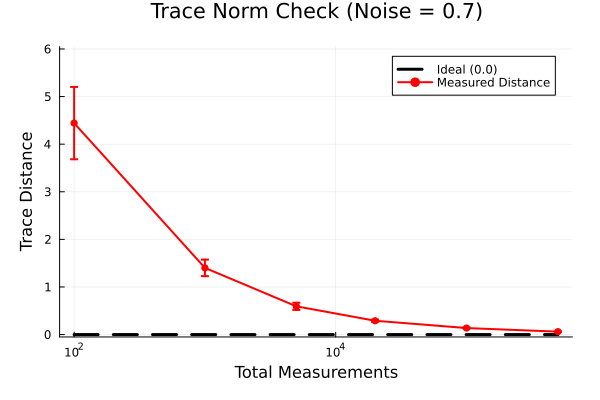

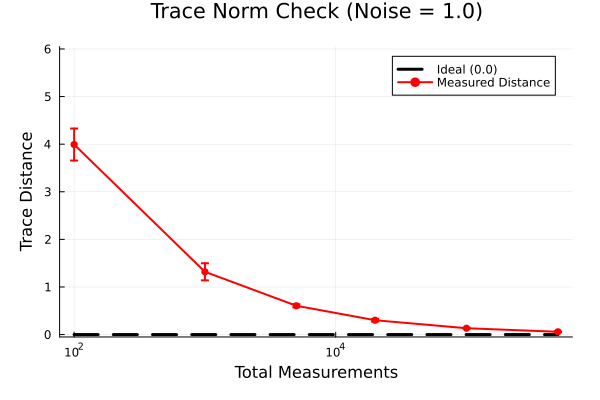

In [55]:
using ITensors
using RandomMeas
using Plots
using Statistics
using LinearAlgebra

# --- 0. 保存先の準備 ---
# 保存先フォルダ名を変更しました
desktop_path = joinpath(homedir(), "Desktop", "GraphResults_TraceNorm")
mkpath(desktop_path)
println("Images will be saved to: $desktop_path")

# --- Helper関数: 頑健なテンソル抽出 ---
function extract_inner_tensor(obj)
    if obj isa ITensor
        return obj
    end
    for name in fieldnames(typeof(obj))
        val = getfield(obj, name)
        if val isa ITensor
            return val
        end
    end
    error("Could not find an ITensor inside type $(typeof(obj)). Fields are: $(fieldnames(typeof(obj)))")
end

# --- Helper関数: 行列化関数 ---
function itensor_to_matrix(T_wrapper, s_inds::Vector{<:Index})
    T = extract_inner_tensor(T_wrapper)
    row_inds = [prime(s) for s in s_inds]
    col_inds = s_inds
    A_multi = Array(T, row_inds..., col_inds...)
    dim_total = 2^length(s_inds)
    return reshape(A_multi, dim_total, dim_total)
end

# MPO用ラッパー
function mpo_to_matrix(m::MPO)
    s = siteinds(m; plev=0)
    return itensor_to_matrix(prod(m), s)
end

# --- ★変更箇所: トレース距離 (Trace Distance) の計算関数 ---
function calculate_trace_distance(ρ::Matrix, σ::Matrix)
    # 差の行列
    diff = ρ - σ
    
    # 数値誤差対策（完全なエルミート行列にする）
    diff = Hermitian(diff + diff') / 2
    
    # 固有値を計算
    vals = eigvals(diff)
    
    # トレースノルム (|ρ - σ|) の半分
    # これにより範囲が 0(一致) 〜 1(完全不一致) になります
    return 0.5 * sum(abs.(vals))
end

# --- 1. 共通設定 ---
N = 4
depth = 5
cutoff = 1e-12

noise_levels = [0.0, 0.1, 0.3, 0.5, 0.7, 1.0]

settings_list = [
    (nu=10,   nm=10),
    (nu=20,   nm=50),
    (nu=50,   nm=100),
    (nu=100,  nm=200),
    (nu=200,  nm=500),
    (nu=500,  nm=1000)
]
n_repeat = 15

ξ = siteinds("Qubit", N)
circuit = random_circuit(ξ, depth)

println("=== Starting Simulation (Trace Distance) ===")

# --- 2. ノイズレベルごとのループ ---
for noise_val in noise_levels
    println("\n--- Processing Noise Strength = $noise_val ---")
    
    p_prior = noise_val * ones(N)
    
    ψ_ideal = MPS(ξ, ["Dn" for n in 1:N])
    ψ2 = outer(ψ_ideal', ψ_ideal)
    
    for d in 1:depth
        ψ2t = apply(circuit, ψ2, apply_dag=true; cutoff=cutoff)
        global ψ2 = apply_depo_channel(ψ2t, p_prior)
    end
    
    true_rho_matrix = itensor_to_matrix(prod(ψ2), ξ)
    
    total_shots_list = Float64[]
    mean_dists = Float64[] # 変数名を変更
    std_dists  = Float64[] # 変数名を変更
    
    for (nu, nm) in settings_list
        total_shots = nu * nm
        push!(total_shots_list, total_shots)
        temp_dists = Float64[]
        
        for i in 1:n_repeat
            mg = MeasurementGroup(ψ2, nu, nm; mode=RandomMeas.Dense)
            shadows = get_dense_shadows(mg)
            
            est_matrix = zeros(ComplexF64, 2^N, 2^N)
            for s in shadows
                est_matrix += itensor_to_matrix(s, ξ)
            end
            est_matrix /= length(shadows)
            
            # ★変更箇所: トレース距離を計算
            dist = calculate_trace_distance(true_rho_matrix, est_matrix)
            push!(temp_dists, dist)
        end
        
        push!(mean_dists, mean(temp_dists))
        push!(std_dists,  std(temp_dists))
    end
    
    # --- プロット ---
    # ★ターゲットを 0.0 に変更 (距離なので0が理想)
    target_line = fill(0.0, length(total_shots_list))
    
    p = plot(total_shots_list, target_line, 
        label="Ideal (0.0)", 
        lw=3, color=:black, linestyle=:dash,
        xlabel="Total Measurements",
        ylabel="Trace Distance",
        title="Trace Norm Check (Noise = $noise_val)",
        legend=:topright,
        xscale=:log10,
        ylims=(-0.05, 6.05), # 見やすいように調整
        margin=5Plots.mm
    )
    
    plot!(p, total_shots_list, mean_dists, 
        yerror=std_dists,
        label="Measured Distance", 
        marker=:circle, lw=2, color=:red, msc=:red # 色を赤に変更
    )
    
    file_name = "trace_norm_noise_$(noise_val).png"
    save_full_path = joinpath(desktop_path, file_name)
    savefig(p, save_full_path)
    println("  -> Saved graph to: $file_name")
    
    display(p)
end